In [2]:
!pip install scikit-learn


  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 5.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.1 MB 4.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 4.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 4.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 4.6 MB/s eta 0:00:01
   ----------------------------------

Accuracy: 0.97847533632287

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



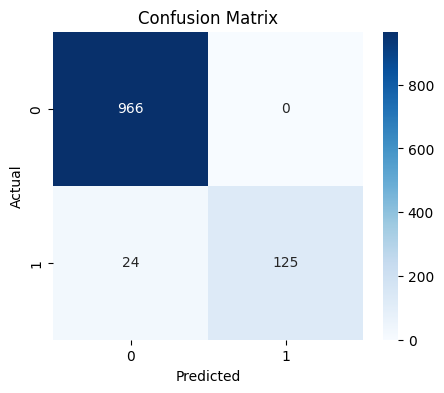

Prediction: Spam


In [3]:
# INTERNSHIP TASK - 4
# MACHINE LEARNING MODEL IMPLEMENTATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
data = pd.read_table(url, header=None, names=["label", "message"])

data.head()
data['label_num'] = data.label.map({'ham': 0, 'spam': 1})

X = data['message']
y = data['label_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
def predict_spam(text):
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)
    return "Spam" if prediction[0] == 1 else "Not Spam"

sample_text = "Congratulations! You have won a free gift card. Click now!"
print("Prediction:", predict_spam(sample_text))